In [31]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist


In [32]:
data = pd.read_csv("diabetes_prediction_dataset.csv")
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [33]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [34]:
data["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [35]:
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])
data['smoking_history'] = le.fit_transform(data['smoking_history'])


In [36]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


<Axes: >

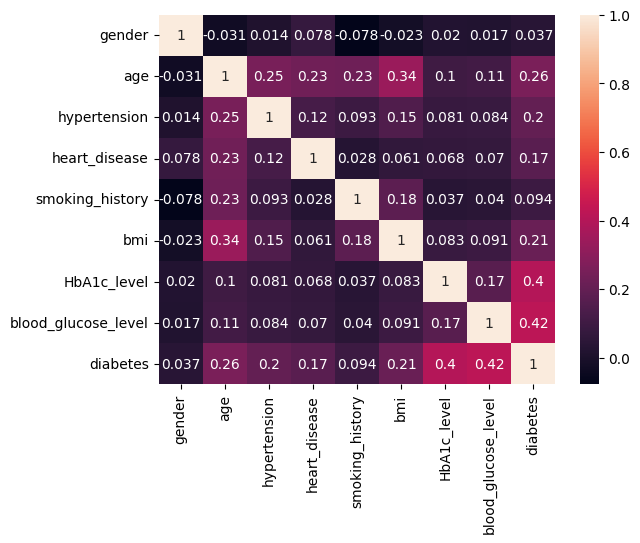

In [37]:
corr = data.corr()
sns.heatmap(corr,annot = True)

In [38]:
data = data.drop(["gender","smoking_history","heart_disease"],axis = 1) 

In [39]:
data

,age,hypertension,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,25.19,6.6,140,0
1,54.0,0,27.32,6.6,80,0
2,28.0,0,27.32,5.7,158,0
3,36.0,0,23.45,5.0,155,0
4,76.0,1,20.14,4.8,155,0
...,...,...,...,...,...,...
99995,80.0,0,27.32,6.2,90,0
99996,2.0,0,17.37,6.5,100,0
99997,66.0,0,27.83,5.7,155,0
99998,24.0,0,35.42,4.0,100,0


In [40]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    
)


In [41]:
model = Sequential()

model.add(Dense(16, input_shape=(5,), activation='relu'))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\Huzaifa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    validation_data = (X_test,y_test)
)

Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9183 - loss: 0.2946 - val_accuracy: 0.9226 - val_loss: 0.2351
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9284 - loss: 0.2227 - val_accuracy: 0.9387 - val_loss: 0.2001
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9345 - loss: 0.1918 - val_accuracy: 0.9458 - val_loss: 0.1768
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9417 - loss: 0.1672 - val_accuracy: 0.9276 - val_loss: 0.1737
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9479 - loss: 0.1500 - val_accuracy: 0.9506 - val_loss: 0.1489
Epoch 6/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9497 - loss: 0.1403 - val_accuracy: 0.9531 - val_loss: 0.1410
Epoch 7/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9531 - loss: 0.1334 - val_accuracy: 0.9556 - val_loss: 0.1234
Epoch 8/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9540 - loss: 0.1306

In [46]:
model.save("model.h5")

In [47]:
loaded_model = load_model("model.h5")


In [48]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Confusion Matrix:
 [[18002   290]
 [  542  1166]]


<Axes: >

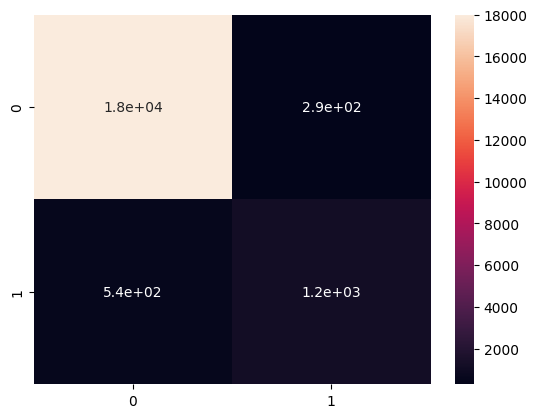

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm,annot = True)

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98     18292
           1       0.80      0.68      0.74      1708

    accuracy                           0.96     20000
   macro avg       0.89      0.83      0.86     20000
weighted avg       0.96      0.96      0.96     20000

